# Shooting Target LSTM Classifier

Classifies shooting-target images into two classes based on the binary ring-pattern
strings extracted from the rectified, binarised images:

| Class | Images | Description |
|---|---|---|
| **0** | `16xx` | target type A |
| **1** | `30xx` | target type B |

**Input per sample:** 4 binary strings of length `SEQ_LEN`, stacked as `(SEQ_LEN, 4)`.
Each string reads from the image centre outward in one of four directions
(`v_top`, `v_bot`, `h_left`, `h_right`).

**Evaluation:** Leave-One-Out cross-validation (LOO-CV) — the only unbiased strategy
with N = 10 samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from itertools import product

import torch
import torch.nn as nn
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, classification_report

print(f'PyTorch {torch.__version__}')
device = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available()          else
    torch.device('cpu')
)
print(f'Device : {device}')

PyTorch 2.11.0
Device : mps


## Config

All hyperparameters in one place.

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("/Users/MortenHelsoe/Desktop/Skole & Arbejde/Git-projects/TargetClassification/data")
DATASET    = DATA_DIR / "lstm_dataset.npz"
MODEL_PATH = DATA_DIR / "lstm_model.pt"

# ── Model ────────────────────────────────────────────────────────────────────
INPUT_SIZE  = 1       # one binary string per sample (exploded: 4 strings per image)
HIDDEN_SIZE = 32      # LSTM hidden units per direction
NUM_LAYERS  = 1       # LSTM stacking depth
DROPOUT     = 0.3     # applied after LSTM output
BIDIRECT    = True    # bidirectional LSTM

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS      = 600
LR          = 1e-3
WEIGHT_DECAY= 1e-4    # L2 regularisation
LOG_EVERY   = 100     # print loss every N epochs during final training

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("Config loaded.")

Config loaded.


## Data

Raw  X  : (9, 894, 4)  (9 images x 894 timesteps x 4 strings)
y        : [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0]
names    : [np.str_('IMG_1664'), np.str_('IMG_1685'), np.str_('IMG_1688'), np.str_('IMG_1690'), np.str_('IMG_1691'), np.str_('IMG_3085'), np.str_('IMG_3090'), np.str_('IMG_3091'), np.str_('IMG_3099')]

Exploded:
X_exp   : (36, 894, 1)  (36 samples x 894 timesteps x 1 feature)
y_exp   : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
groups  : [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8]

Exploded class 0 (16xx): 20   class 1 (30xx): 16


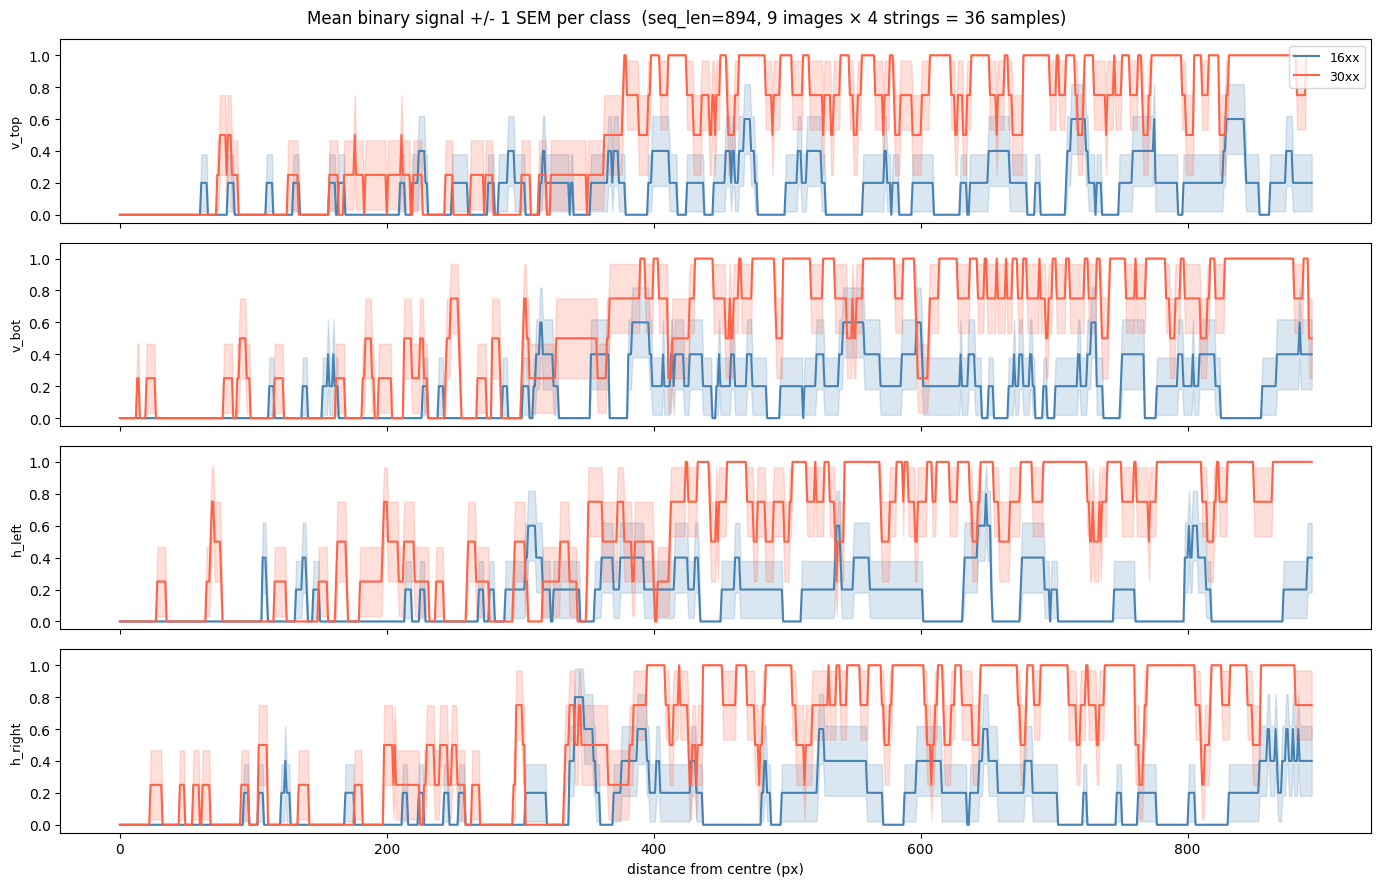

In [3]:
data  = np.load(str(DATASET), allow_pickle=True)
X_np  = data["X"].astype(np.float32)   # (N, SEQ_LEN, 4)
y_np  = data["y"].astype(np.float32)   # (N,)
names = data["names"]                  # (N,) image names

N, SEQ_LEN, N_FEAT = X_np.shape
print(f"Raw  X  : {X_np.shape}  ({N} images x {SEQ_LEN} timesteps x {N_FEAT} strings)")
print(f"y        : {y_np.tolist()}")
print(f"names    : {list(names)}")

# ── Explode: each string becomes its own independent sample ───────────────────
# X_np (N, SEQ_LEN, 4)  →  transpose  →  (N, 4, SEQ_LEN)  →  reshape  →  (N*4, SEQ_LEN, 1)
# Row i*4+j  =  string j of image i   (j: 0=v_top, 1=v_bot, 2=h_left, 3=h_right)
X_exp  = X_np.transpose(0, 2, 1).reshape(N * 4, SEQ_LEN, 1).astype(np.float32)
y_exp  = np.repeat(y_np, 4).astype(np.float32)
groups = np.repeat(np.arange(N), 4)   # group id = source image index
N_EXP  = len(X_exp)

feat_names = ["v_top", "v_bot", "h_left", "h_right"]
print(f"\nExploded:")
print(f"X_exp   : {X_exp.shape}  ({N_EXP} samples x {SEQ_LEN} timesteps x 1 feature)")
print(f"y_exp   : {y_exp.tolist()}")
print(f"groups  : {groups.tolist()}")

counts = {int(c): int(n) for c, n in zip(*np.unique(y_exp, return_counts=True))}
print(f"\nExploded class 0 (16xx): {counts[0]}   class 1 (30xx): {counts[1]}")

# ── Mean signal per string direction and class ───────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
x_axis = np.arange(SEQ_LEN)

for row, (ax, feat) in enumerate(zip(axes, feat_names)):
    for label, color, cls in [(0, "steelblue", "16xx"), (1, "tomato", "30xx")]:
        idx  = np.where(y_np == label)[0]
        vals = X_np[idx, :, row]          # (n_imgs_in_class, SEQ_LEN)
        mean = vals.mean(axis=0)
        sem  = vals.std(axis=0) / max(np.sqrt(len(idx)), 1)
        ax.plot(x_axis, mean, color=color, linewidth=1.5, label=cls)
        ax.fill_between(x_axis, mean - sem, mean + sem, color=color, alpha=0.2)
    ax.set_ylabel(feat, fontsize=9)
    ax.set_ylim(-0.05, 1.1)
    if row == 0:
        ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("distance from centre (px)", fontsize=10)
fig.suptitle(
    f"Mean binary signal +/- 1 SEM per class  "
    f"(seq_len={SEQ_LEN}, {N} images × 4 strings = {N_EXP} samples)",
    fontsize=12
)
plt.tight_layout()
plt.show()

## Model — Bidirectional LSTM

```
Input  (batch, 894, 1)          ← one binary string per sample
  ↓
BiLSTM(hidden=32, layers=1)   → concat final hidden states  (batch, 64)
  ↓
Dropout(0.3)
  ↓
Linear(64 → 1)                → raw logit
  ↓
BCEWithLogitsLoss / sigmoid   → binary prediction
```

Each image is **exploded** into 4 independent training samples (one per string direction:
`v_top`, `v_bot`, `h_left`, `h_right`). During LOO-CV the 4 per-string probabilities
from the held-out image are **averaged** to produce one image-level prediction.

In [4]:
class TargetLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, bidirectional):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = bidirectional,
            dropout       = dropout if num_layers > 1 else 0.0,
        )
        dirs = 2 if bidirectional else 1
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size * dirs, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        _, (hn, _) = self.lstm(x)
        # hn: (num_layers * dirs, batch, hidden_size)
        if self.lstm.bidirectional:
            h = torch.cat([hn[-2], hn[-1]], dim=1)   # (batch, hidden*2)
        else:
            h = hn[-1]                                # (batch, hidden)
        return self.fc(self.drop(h)).squeeze(-1)      # (batch,) raw logits


# ── Sanity check ─────────────────────────────────────────────────────────────
_m = TargetLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, BIDIRECT).to(device)
_x = torch.zeros(3, SEQ_LEN, INPUT_SIZE, device=device)
print(f"Output shape on dummy batch (size 3): {_m(_x).shape}")
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del _m, _x

Output shape on dummy batch (size 3): torch.Size([3])
Trainable parameters: 9,025


## Training helpers

In [5]:
def make_model():
    torch.manual_seed(SEED)
    return TargetLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, BIDIRECT).to(device)


def train_fold(X_train, y_train, verbose=False):
    """Train a fresh model on (X_train, y_train). Returns (model, loss_history)."""
    model     = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # Per-fold class-weighted loss to handle imbalance
    n_pos      = float(y_train.sum())
    n_neg      = len(y_train) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    X_t = torch.tensor(X_train, device=device)
    y_t = torch.tensor(y_train, device=device)

    history = []
    model.train()
    for epoch in range(1, EPOCHS + 1):
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if verbose and epoch % LOG_EVERY == 0:
            print(f"  epoch {epoch:4d}/{EPOCHS}  loss={loss.item():.4f}")

    return model, history


@torch.no_grad()
def predict(model, X_test):
    """Return (probabilities, binary predictions) for each row in X_test."""
    model.eval()
    X_t   = torch.tensor(X_test, device=device)
    probs = torch.sigmoid(model(X_t)).cpu().numpy()
    preds = (probs >= 0.5).astype(int)
    return probs, preds


print("Helpers defined.")

Helpers defined.


## Leave-One-Out Cross-Validation (group-aware)

Each fold holds out **all 4 strings from one image** for testing and trains on the
remaining 36 strings (9 images × 4). `LeaveOneGroupOut` guarantees no string from
the test image ever leaks into training.

The 4 per-string probabilities from the held-out image are **averaged** into a single
image-level prediction. Loss history and final accuracy are reported at image level.

In [6]:
logo      = LeaveOneGroupOut()
all_true  = []
all_pred  = []
all_prob  = []   # image-level averaged probability
all_hist  = []   # one loss curve per fold

n_folds = logo.get_n_splits(X_exp, y_exp, groups=groups)
print(f"Running {n_folds}-fold group LOO-CV   ({EPOCHS} epochs per fold)")
print(f"  Train: {N_EXP - 4} strings (9 images × 4)   Test: 4 strings → averaged\n")
print(f"  {'Fold':>4}  {'Test image':<20} {'True':>5} {'Pred':>5} {'AvgProb':>8}  OK?")
print(f"  {chr(9472)*62}")

for fold, (train_idx, test_idx) in enumerate(logo.split(X_exp, y_exp, groups=groups)):
    X_train, X_test = X_exp[train_idx], X_exp[test_idx]
    y_train, y_test = y_exp[train_idx], y_exp[test_idx]

    model, history = train_fold(X_train, y_train)
    probs, _       = predict(model, X_test)   # shape (4,) — one prob per string

    # Aggregate: average 4 string probabilities → one image-level prediction
    avg_prob = float(probs.mean())
    pred     = int(avg_prob >= 0.5)
    true     = int(y_test[0])                 # all 4 strings share the same label
    ok       = chr(10003) if pred == true else chr(10007)

    all_true.append(true)
    all_pred.append(pred)
    all_prob.append(avg_prob)
    all_hist.append(history)

    img_idx = groups[test_idx[0]]
    print(f"  {fold+1:>4}  {names[img_idx]:<20} {true:>5} {pred:>5} {avg_prob:>8.3f}  {ok}")

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_prob = np.array(all_prob)

acc = (all_true == all_pred).mean()
print(f"\nLOO Accuracy: {acc*100:.1f}%   ({int((all_true==all_pred).sum())}/{N} correct)")

Running 9-fold group LOO-CV   (600 epochs per fold)
  Train: 32 strings (9 images × 4)   Test: 4 strings → averaged

  Fold  Test image            True  Pred  AvgProb  OK?
  ──────────────────────────────────────────────────────────────
     1  IMG_1664                 0     0    0.471  ✓
     2  IMG_1685                 0     0    0.014  ✓
     3  IMG_1688                 0     0    0.012  ✓
     4  IMG_1690                 0     0    0.008  ✓
     5  IMG_1691                 0     0    0.462  ✓
     6  IMG_3085                 1     1    0.501  ✓
     7  IMG_3090                 1     1    0.843  ✓
     8  IMG_3091                 1     1    0.994  ✓
     9  IMG_3099                 1     1    0.987  ✓

LOO Accuracy: 100.0%   (9/9 correct)


## Results

                precision    recall  f1-score   support

Class 0 (16xx)       1.00      1.00      1.00         5
Class 1 (30xx)       1.00      1.00      1.00         4

      accuracy                           1.00         9
     macro avg       1.00      1.00      1.00         9
  weighted avg       1.00      1.00      1.00         9



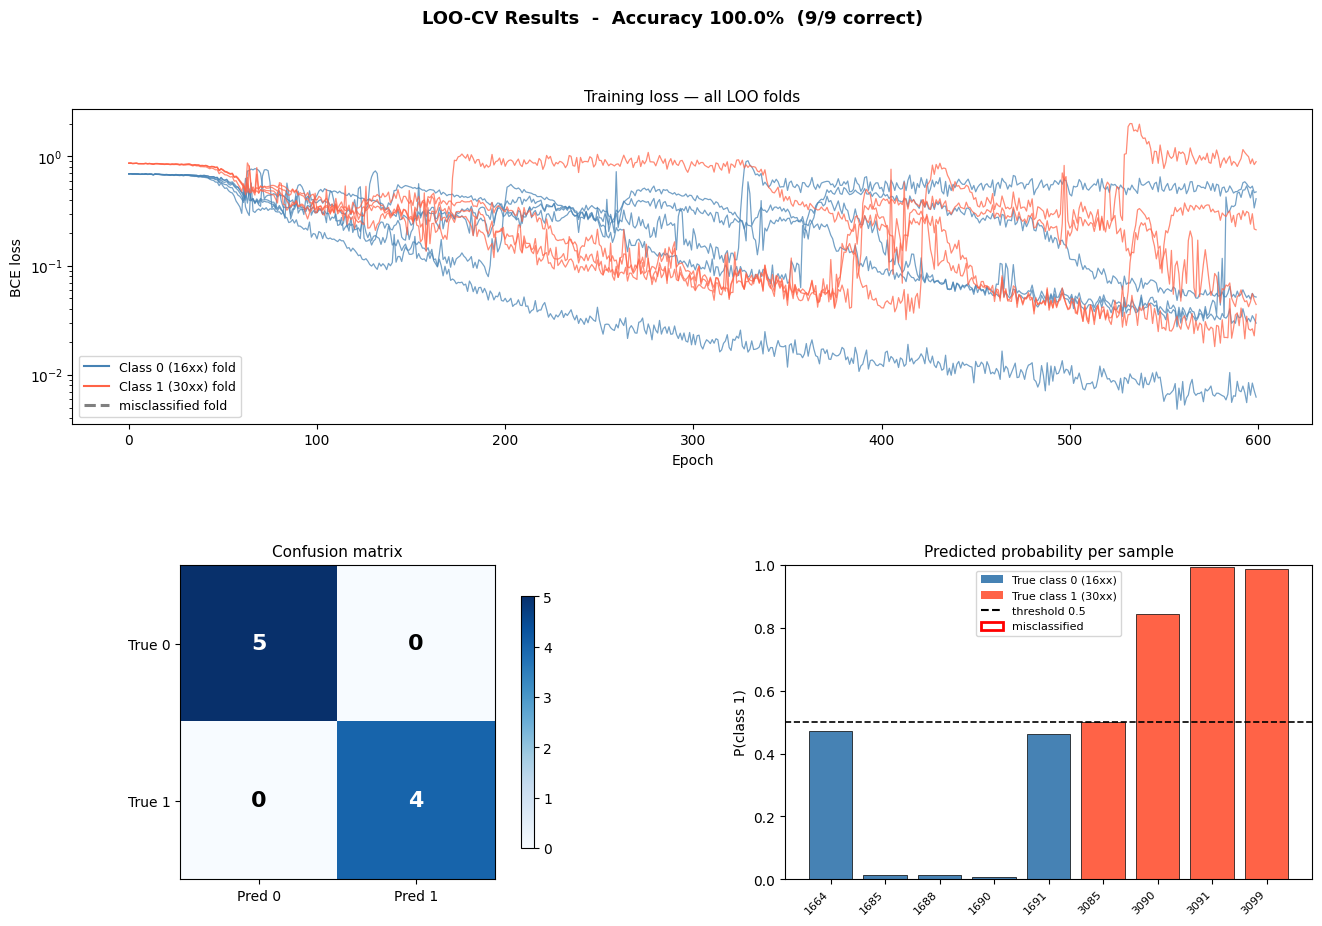

In [7]:
# ── Classification report ────────────────────────────────────────────────────
print(classification_report(all_true, all_pred,
                             target_names=["Class 0 (16xx)", "Class 1 (30xx)"],
                             zero_division=0))

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── (a) Loss curves ──────────────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, :])
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

for fold_i, (hist, true, pred) in enumerate(zip(all_hist, all_true, all_pred)):
    color = "steelblue" if true == 0 else "tomato"
    lw    = 2.2 if true != pred else 0.9
    ls    = "--" if true != pred else "-"
    ax_loss.plot(hist, color=color, linewidth=lw, linestyle=ls, alpha=0.75)

proxies = [
    Line2D([0],[0], color="steelblue", lw=1.5, label="Class 0 (16xx) fold"),
    Line2D([0],[0], color="tomato",    lw=1.5, label="Class 1 (30xx) fold"),
    Line2D([0],[0], color="gray",      lw=2.2, ls="--", label="misclassified fold"),
]
ax_loss.legend(handles=proxies, fontsize=9)
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("BCE loss")
ax_loss.set_title("Training loss — all LOO folds", fontsize=11)
ax_loss.set_yscale("log")

# ── (b) Confusion matrix ─────────────────────────────────────────────────────
ax_cm = fig.add_subplot(gs[1, 0])
cm    = confusion_matrix(all_true, all_pred)
im    = ax_cm.imshow(cm, cmap="Blues", vmin=0)
plt.colorbar(im, ax=ax_cm, shrink=0.8)
for (r, c), val in zip(product(range(2), range(2)), cm.flatten()):
    ax_cm.text(c, r, str(val), ha='center', va='center',
               fontsize=16, fontweight='bold',
               color='white' if val > cm.max()/2 else 'black')
ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(['Pred 0','Pred 1'])
ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(['True 0','True 1'])
ax_cm.set_title('Confusion matrix', fontsize=11)

# ── (c) Predicted probabilities ──────────────────────────────────────────────
ax_prob = fig.add_subplot(gs[1, 1])
bar_colors = ["steelblue" if t == 0 else "tomato" for t in all_true]
for i, (prob, color) in enumerate(zip(all_prob, bar_colors)):
    ec = 'red' if all_pred[i] != all_true[i] else 'black'
    lw = 2.5  if all_pred[i] != all_true[i] else 0.5
    ax_prob.bar(i, prob, color=color, edgecolor=ec, linewidth=lw)

ax_prob.axhline(0.5, color='black', linestyle='--', linewidth=1.2)
ax_prob.set_xticks(range(N))
ax_prob.set_xticklabels([n.replace('IMG_','') for n in names],
                         rotation=45, ha='right', fontsize=8)
ax_prob.set_ylabel('P(class 1)')
ax_prob.set_ylim(0, 1)
ax_prob.set_title('Predicted probability per sample', fontsize=11)
ax_prob.legend(handles=[
    Patch(facecolor='steelblue', label='True class 0 (16xx)'),
    Patch(facecolor='tomato',    label='True class 1 (30xx)'),
    Line2D([0],[0], color='black', ls='--', label='threshold 0.5'),
    Patch(edgecolor='red', facecolor='none', linewidth=2, label='misclassified'),
], fontsize=8, loc='upper center')

fig.suptitle(
    f'LOO-CV Results  -  Accuracy {acc*100:.1f}%  ({int((all_true==all_pred).sum())}/{N} correct)',
    fontsize=13, fontweight='bold'
)
plt.show()

## Final model — trained on all data

Train one model on the complete dataset and save to disk.
The LOO accuracy above is the unbiased performance estimate — the training-set
accuracy printed here is optimistic and not a valid metric.

Training final model on all 36 exploded samples (9 images × 4 strings) for 600 epochs ...

  epoch  100/600  loss=0.4664
  epoch  200/600  loss=0.3398
  epoch  300/600  loss=0.3139
  epoch  400/600  loss=0.2012
  epoch  500/600  loss=0.1233
  epoch  600/600  loss=0.0712


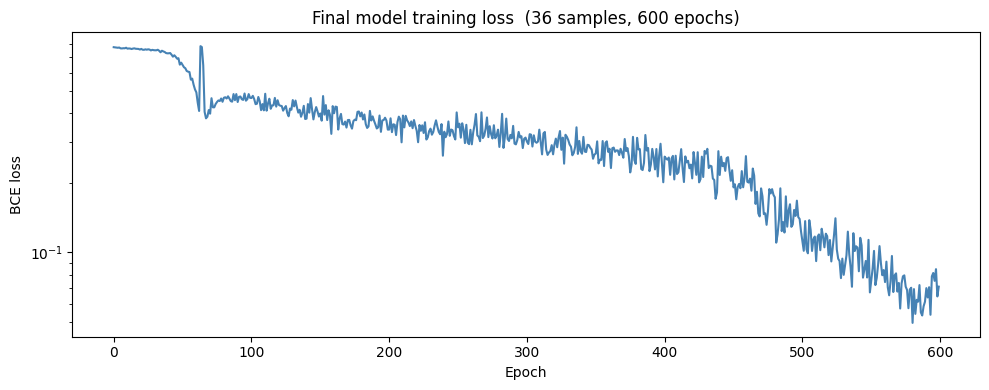


Model saved -> /Users/MortenHelsoe/Desktop/Skole & Arbejde/Git-projects/TargetClassification/data/lstm_model.pt
Training-set accuracy on strings (informative): 100.0%  (36 strings)
Training-set accuracy on images  (informative): 100.0%  (9 images)
LOO accuracy (unbiased estimate)              : 100.0%  (9 images)


In [8]:
print(f"Training final model on all {N_EXP} exploded samples ({N} images × 4 strings) for {EPOCHS} epochs ...\n")
final_model, final_hist = train_fold(X_exp, y_exp, verbose=True)

# ── Training curve ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(final_hist, color='steelblue', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE loss')
ax.set_yscale('log')
ax.set_title(f'Final model training loss  ({N_EXP} samples, {EPOCHS} epochs)')
plt.tight_layout()
plt.show()

# ── Save ─────────────────────────────────────────────────────────────────────
torch.save({
    'model_state': final_model.state_dict(),
    'config': {
        'input_size':    INPUT_SIZE,
        'hidden_size':   HIDDEN_SIZE,
        'num_layers':    NUM_LAYERS,
        'dropout':       DROPOUT,
        'bidirectional': BIDIRECT,
        'seq_len':       SEQ_LEN,
    },
    'names':        list(names),
    'loo_accuracy': float(acc),
}, str(MODEL_PATH))
print(f"\nModel saved -> {MODEL_PATH}")

# ── Self-check on all exploded samples (informative only) ────────────────────
probs_all, preds_all = predict(final_model, X_exp)
train_acc_str = (preds_all == y_exp.astype(int)).mean()

# Image-level: average 4 string probs per image
probs_img = probs_all.reshape(N, 4).mean(axis=1)
preds_img = (probs_img >= 0.5).astype(int)
train_acc_img = (preds_img == y_np.astype(int)).mean()

print(f"Training-set accuracy on strings (informative): {train_acc_str*100:.1f}%  ({N_EXP} strings)")
print(f"Training-set accuracy on images  (informative): {train_acc_img*100:.1f}%  ({N} images)")
print(f"LOO accuracy (unbiased estimate)              : {acc*100:.1f}%  ({N} images)")